<a href="https://colab.research.google.com/github/PriyaVerma06/Linear-Regression/blob/feature-correlation-analysis/feature_target_correlation_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('https://raw.githubusercontent.com/PriyaVerma06/Linear-Regression/main/dataset.csv')

df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Concrete compressive strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Cement                         1030 non-null   float64
 1   Blast Furnace Slag             1030 non-null   float64
 2   Fly Ash                        1030 non-null   float64
 3   Water                          1030 non-null   float64
 4   Superplasticizer               1030 non-null   float64
 5   Coarse Aggregate               1030 non-null   float64
 6   Fine Aggregate                 1030 non-null   float64
 7   Age                            1030 non-null   int64  
 8   Concrete compressive strength  1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [7]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Concrete compressive strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [8]:
df.shape

(1030, 9)

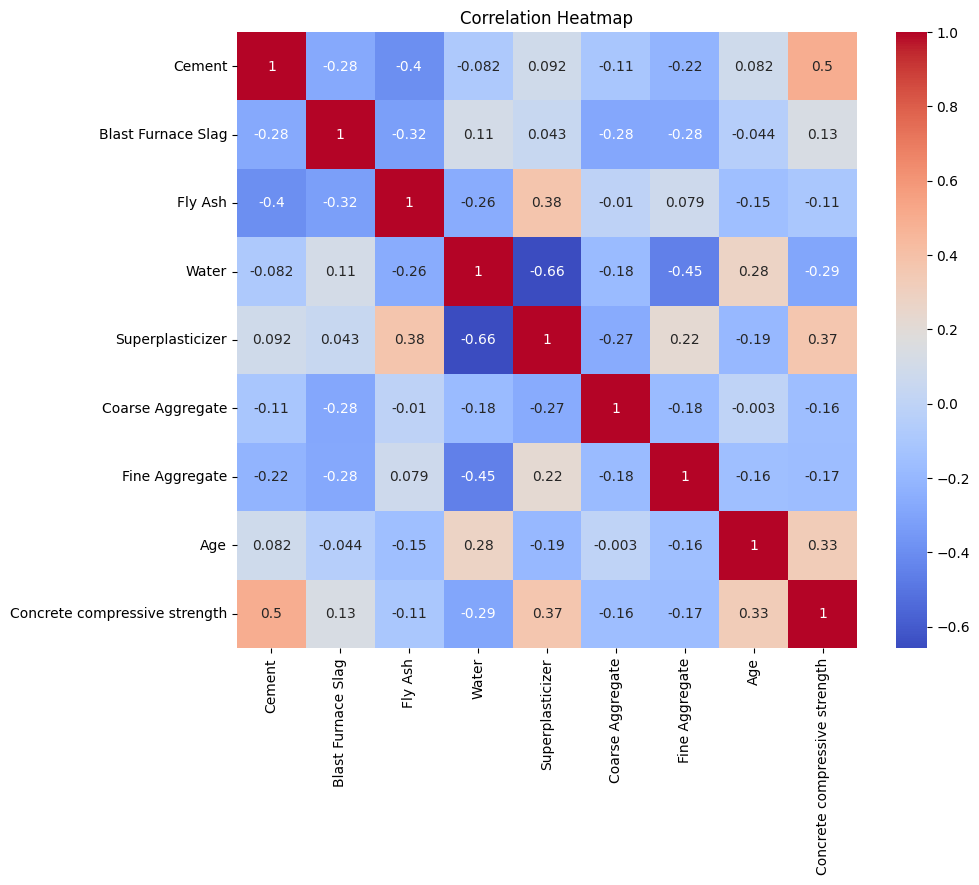

In [9]:
plt.figure(figsize=(10,8))
corr = df.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [10]:
target = 'Concrete compressive strength'

corr_target = corr[target].drop(target)

# Absolute correlation ranking
corr_sorted = corr_target.abs().sort_values(ascending=False)

corr_sorted

,Concrete compressive strength
Cement,0.497832
Superplasticizer,0.366079
Age,0.328873
Water,0.289633
Fine Aggregate,0.167241
Coarse Aggregate,0.164935
Blast Furnace Slag,0.134829
Fly Ash,0.105755


In [11]:
top5 = corr_sorted.head(5).index
top5

Index(['Cement', 'Superplasticizer', 'Age', 'Water', 'Fine Aggregate'], dtype='object')

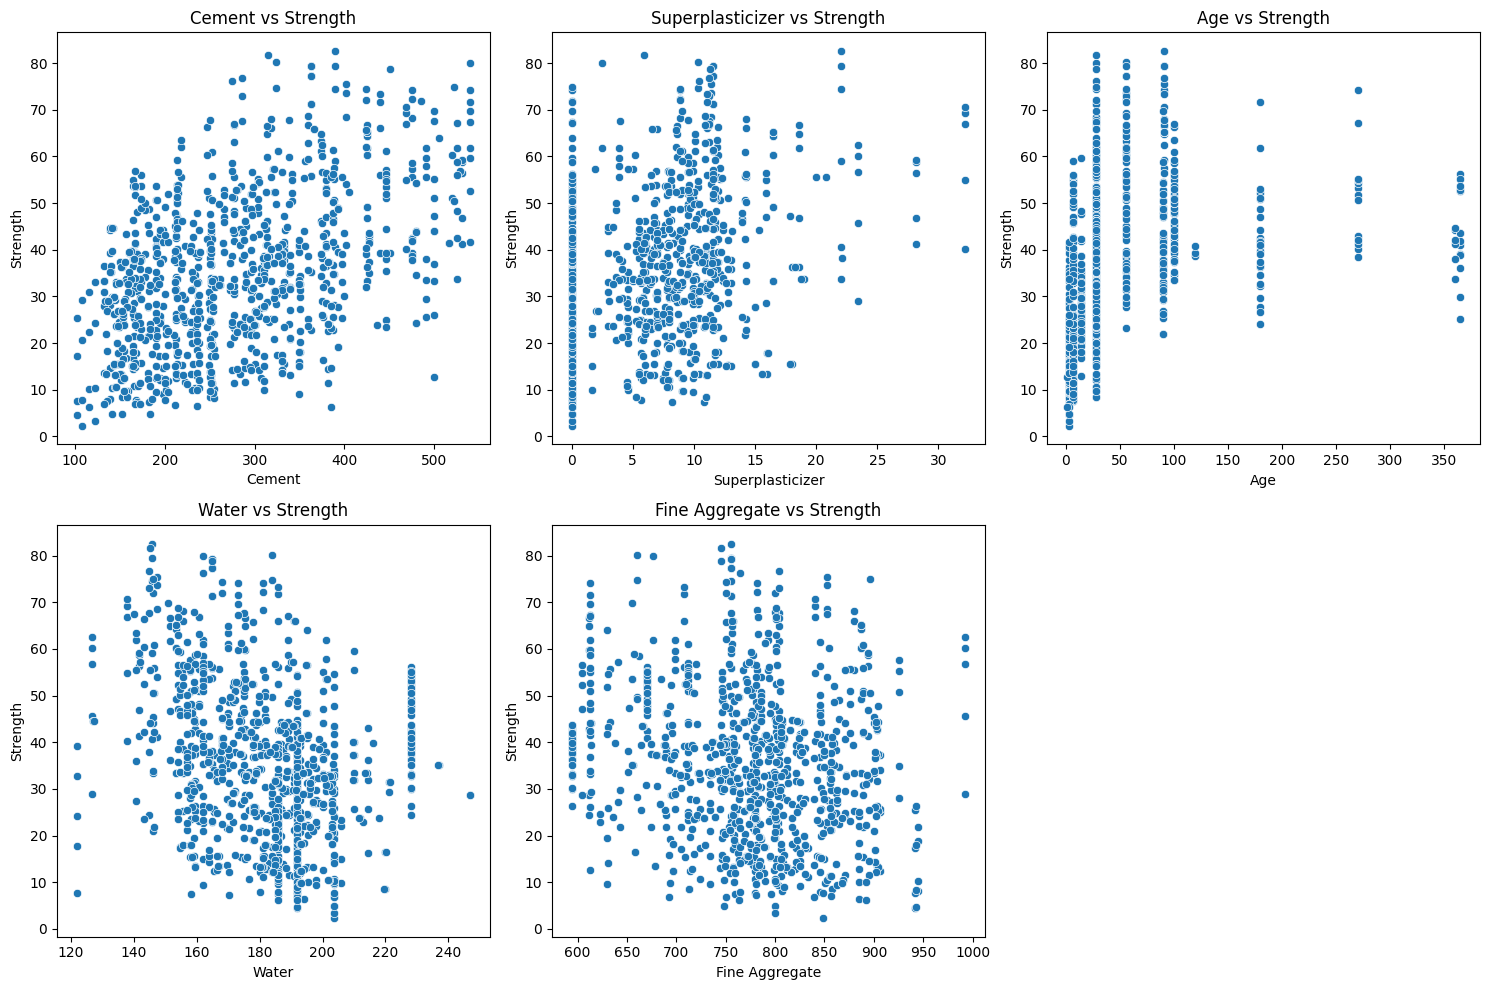

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

target = 'Concrete compressive strength'

# Top 5 features (assuming already computed)
top5 = corr_sorted.head(5).index

plt.figure(figsize=(15,10))

for i, feature in enumerate(top5, 1):
    plt.subplot(2, 3, i)
    sns.scatterplot(x=df[feature], y=df[target])
    plt.title(f"{feature} vs Strength")
    plt.xlabel(feature)
    plt.ylabel("Strength")

plt.tight_layout()
plt.show()

## Feature Importance Summary

-Cement is the most important feature, as it shows a strong positive relationship with compressive strength — higher cement content leads to stronger concrete.

-Water has a negative impact, meaning excess water reduces strength by weakening the mixture.

-Superplasticizer is also significant, as it improves workability while maintaining or increasing strength.

-Age plays a key role, since concrete strength increases over time due to curing.

-Other features like aggregates show weaker relationships, indicating they have less direct influence individually.
